# Power via Simulation
**Authors:** Emily Griffith and John Slankas  
**Date:** 2026-03-11

## Power Calculations

Power is the ability to detect a false null hypothesis.

It depends on several factors, including the:

* effect size of interest,
* number of observations,
* variability of the observed process, and
* study design.

#### Why calculate power?

1. Power calculations are very helpful in making sure that you have a clearly articulated research question and a designed study.
    * Power calculations require knowing what you're measuring, what you expect those values to be, and what kind of difference you'd like to detect.

2. Power calculations help keep your research honest!
    * Performing power calculations can help prevent issues like cherry-picking or p-hacking because they require careful planning.

3. Power calculations help make sure you don't waste your time
    * An underpowered study may not be worth doing.

#### Power calculation examples:

The goal of a study with a hypothesis test is to make a decision.

We have systolic blood pressure on suspected COVID-19 cases in our synthetic dataset based on OMOP data.

The mean systolic blood pressure is 121 (standard deviation of 13) for patients with suspected COVID-19.

The overall systolic blood pressure is 120 (standard deviation of 13) for patients.

### Designing a simulation study:

1. What are our aims and objectives?

We want to see if suspected COVID-19 patients present with higher systolic blood pressure than other patients.

2. How will you generate the data?

We have systolic blood pressure on suspected COVID-19 cases in our synthetic dataset based on OMOP data.  
The mean systolic blood pressure is 121 (standard deviation of 13) for patients with suspected COVID-19.  
The overall systolic blood pressure is 120 (standard deviation of 13) for patients.

We can generate data from two normal distributions-- one for suspected COVID-19 and one for other patients.

3. Which scenarios will you investigate?

We can investigate equal numbers of patients per group in increasing increments of 50.

4. What statistical analysis method(s) will be used?

Comparisons will be made using a two-sample t-test.

5. What estimates will you store for each simulation?

We can store:
* the mean difference
* the t-statistic
* the p-value

6. How many simulations will you run?

We will run 10,000 simulations.

7. How will you evaluate the results?

We will examine the proportion of p-values that are below 0.05.

8. How will you present the results?

We will present the results in a table and a plot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(311)

# select sample size
n = 50
sims = 1000

# create lists to store values we'll save
pvals = np.ones(sims)
tvals = np.ones(sims)
meandiffs = np.ones(sims)

for i in range(sims):
    # generate data
    null_bp = np.random.normal(loc=120, scale=13, size=n)
    covid_bp = np.random.normal(loc=121, scale=13, size=n)

    # perform the t-test
    result = stats.ttest_ind(null_bp, covid_bp)

    # save the results
    pvals[i] = result.pvalue
    tvals[i] = result.statistic
    meandiffs[i] = np.mean(null_bp) - np.mean(covid_bp)

Now that we have these values, let's look at them!

The red dotted lines indicate statistical significance (at the 0.05-level).

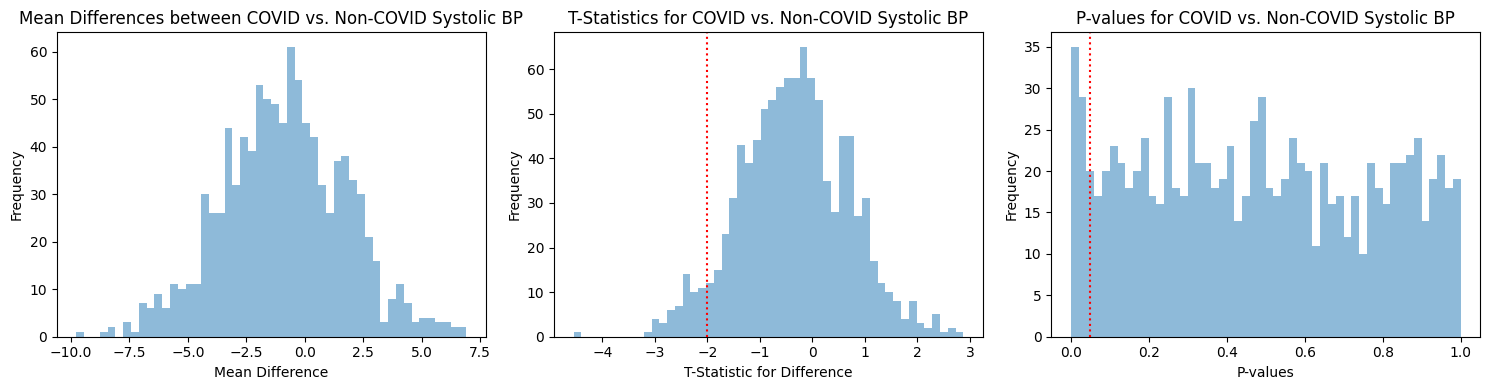

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(meandiffs, bins=50, alpha=0.5)
axes[0].set_title("Mean Differences between COVID vs. Non-COVID Systolic BP")
axes[0].set_xlabel("Mean Difference")
axes[0].set_ylabel("Frequency")

t_crit = stats.t.ppf(0.025, df=n - 1)
axes[1].hist(tvals, bins=50, alpha=0.5)
axes[1].axvline(x=t_crit, linestyle="dotted", color="red", linewidth=1.5)
axes[1].set_title("T-Statistics for COVID vs. Non-COVID Systolic BP")
axes[1].set_xlabel("T-Statistic for Difference")
axes[1].set_ylabel("Frequency")

axes[2].hist(pvals, bins=50, alpha=0.5)
axes[2].axvline(x=0.05, linestyle="dotted", color="red", linewidth=1.5)
axes[2].set_title("P-values for COVID vs. Non-COVID Systolic BP")
axes[2].set_xlabel("P-values")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [3]:
# Calculate power
power = np.sum(pvals < 0.05) / len(pvals)
print(power)

0.073


This example is looking at a **very** small difference, meaning that we have very low power with a small sample size. Let's do the same exercise, but we'll increase the sample size to 1,000 patients per group.

In [4]:
np.random.seed(311)

# select sample size
n = 1000
sims = 1000

# create lists to store values we'll save
pvals = np.ones(sims)
tvals = np.ones(sims)
meandiffs = np.ones(sims)

for i in range(sims):
    # generate data
    null_bp = np.random.normal(loc=120, scale=13, size=n)
    covid_bp = np.random.normal(loc=121, scale=13, size=n)

    # perform the t-test
    result = stats.ttest_ind(null_bp, covid_bp)

    # save the results
    pvals[i] = result.pvalue
    tvals[i] = result.statistic
    meandiffs[i] = np.mean(null_bp) - np.mean(covid_bp)

Now that we have these values, let's look at them!

The red dotted lines indicate statistical significance (at the 0.05-level).

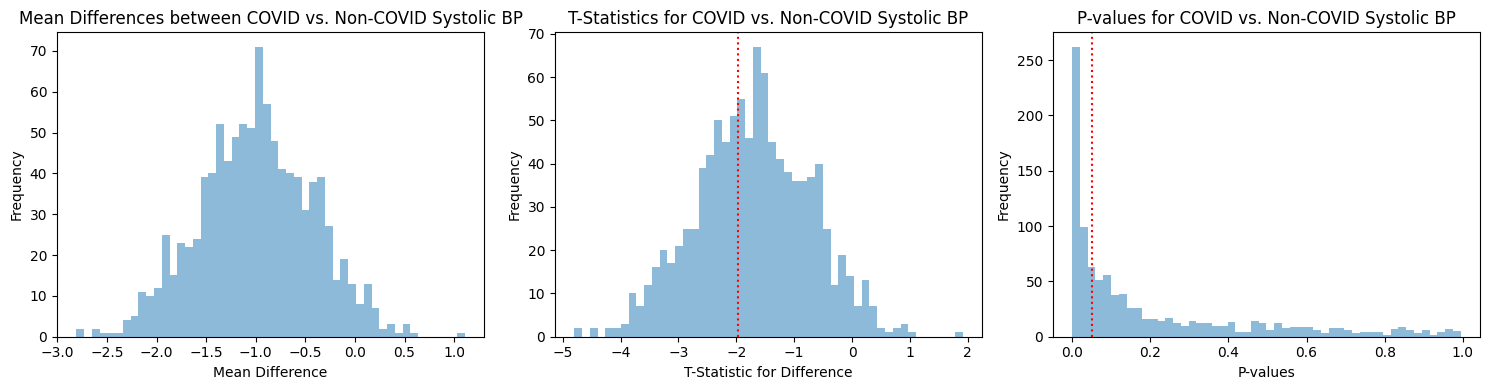

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(meandiffs, bins=50, alpha=0.5)
axes[0].set_title("Mean Differences between COVID vs. Non-COVID Systolic BP")
axes[0].set_xlabel("Mean Difference")
axes[0].set_ylabel("Frequency")

t_crit = stats.t.ppf(0.025, df=n - 1)
axes[1].hist(tvals, bins=50, alpha=0.5)
axes[1].axvline(x=t_crit, linestyle="dotted", color="red", linewidth=1.5)
axes[1].set_title("T-Statistics for COVID vs. Non-COVID Systolic BP")
axes[1].set_xlabel("T-Statistic for Difference")
axes[1].set_ylabel("Frequency")

axes[2].hist(pvals, bins=50, alpha=0.5)
axes[2].axvline(x=0.05, linestyle="dotted", color="red", linewidth=1.5)
axes[2].set_title("P-values for COVID vs. Non-COVID Systolic BP")
axes[2].set_xlabel("P-values")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [6]:
# Calculate power
power = np.sum(pvals < 0.05) / len(pvals)
print(power)

0.397


The power is still pretty low, but it's higher than it was!

We can also make it easier to try different values of n by writing a function for our code.

In [7]:
def twosampt_power(mean1, mean2, sd, n, sims, seed):
    np.random.seed(seed)

    # create lists to store values we'll save
    pvals = np.ones(sims)
    tvals = np.ones(sims)
    meandiffs = np.ones(sims)

    for i in range(sims):
        # generate data
        null_bp = np.random.normal(loc=mean1, scale=sd, size=n)
        covid_bp = np.random.normal(loc=mean2, scale=sd, size=n)

        # perform the t-test
        result = stats.ttest_ind(null_bp, covid_bp)

        # save the results
        pvals[i] = result.pvalue
        tvals[i] = result.statistic
        meandiffs[i] = np.mean(null_bp) - np.mean(covid_bp)

    power = np.sum(pvals < 0.05) / len(pvals)
    return power


print(twosampt_power(mean1=120, mean2=121, sd=13, n=50, sims=1000, seed=919))

0.068


Now that we have a function, we can explore different sample sizes!

In [8]:
print(twosampt_power(mean1=120, mean2=121, sd=13, n=500,  sims=1000, seed=919))
print(twosampt_power(mean1=120, mean2=121, sd=13, n=750,  sims=1000, seed=919))
print(twosampt_power(mean1=120, mean2=121, sd=13, n=1000, sims=1000, seed=919))
print(twosampt_power(mean1=120, mean2=121, sd=13, n=1250, sims=1000, seed=919))
print(twosampt_power(mean1=120, mean2=121, sd=13, n=1500, sims=1000, seed=919))

0.218
0.329
0.428
0.468
0.552


### Main concepts

1. Data generation and statistical analysis are **critically important** for doing power via simulation.

2. If possible, use a small real dataset to figure out your analysis plan.

3. Try a lot of different things to see what the landscape of power looks like.